In [1]:
!pip install medmnist torch torchvision matplotlib scikit-learn torchinfo seaborn

import medmnist
from medmnist import OCTMNIST
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

trainDataSet = OCTMNIST(split="train", download=True, transform=transform)
testDatasSet = OCTMNIST(split="test", download=True, transform=transform)
valDataSet = OCTMNIST(split="val", download=True, transform=transform)

print(f"Train Dataset samples: {len(trainDataSet)}")
print(f"Test Dataset samples: {len(testDatasSet)} ")
print(f"Validation Dataset samples: {len(valDataSet)}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 66.2 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=b

100%|██████████| 54.9M/54.9M [00:05<00:00, 10.6MB/s]


Using downloaded and verified file: /root/.medmnist/octmnist.npz
Using downloaded and verified file: /root/.medmnist/octmnist.npz
Train Dataset samples: 97477
Test Dataset samples: 1000 
Validation Dataset samples: 10832


DATA STATISTICS

In [2]:

trainLabels = np.array([label[0] for _, label in trainDataSet])
testLabels = np.array([label[0] for _, label in testDatasSet])
valLabels = np.array([label[0] for _, label in valDataSet])
transformWithoutNorm = transforms.Compose([transforms.ToTensor()])

trainDatasetWithoutNorm = OCTMNIST(split="train", download=True, transform=transformWithoutNorm)
testDatasetWithoutNorm = OCTMNIST(split="test", download=True, transform=transformWithoutNorm)
valDatasetWithoutNorm = OCTMNIST(split="val", download=True, transform=transformWithoutNorm)

trainImages = np.array([image.numpy() for image, _ in trainDatasetWithoutNorm]).flatten()
testImages = np.array([image.numpy() for image, _ in testDatasetWithoutNorm]).flatten()
valImages = np.array([image.numpy() for image, _ in valDatasetWithoutNorm]).flatten()


allImages = np.concatenate([trainImages, testImages, valImages])

#Mean and Standard Deviation
meanIntensity = np.mean(allImages)
stdDeviation = np.std(allImages)

#pixel intensity
minPixelVals = np.min(allImages)
maxPixelVals = np.max(allImages)
missingVals = np.isnan(allImages).sum()

#stats output
print("Distribution\n")
print("Training Labels:\n", np.bincount(trainLabels))
print("Testing Labels:\n", np.bincount(testLabels))
print("Validation Labels:\n", np.bincount(valLabels))
print(f"Mean Pixel Intensity: {meanIntensity:.4f}")
print(f"Standard Deviation: {stdDeviation:.4f}")
print(f"Minimum Pixel Value: {minPixelVals}")
print(f"Maximum Pixel Value: {maxPixelVals}")
print(f"Missing Values: {missingVals}")

Using downloaded and verified file: /root/.medmnist/octmnist.npz
Using downloaded and verified file: /root/.medmnist/octmnist.npz
Using downloaded and verified file: /root/.medmnist/octmnist.npz
Distribution

Training Labels:
 [33484 10213  7754 46026]
Testing Labels:
 [250 250 250 250]
Validation Labels:
 [3721 1135  862 5114]
Mean Pixel Intensity: 0.1890
Standard Deviation: 0.1964
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0
Missing Values: 0


3 Visualizations


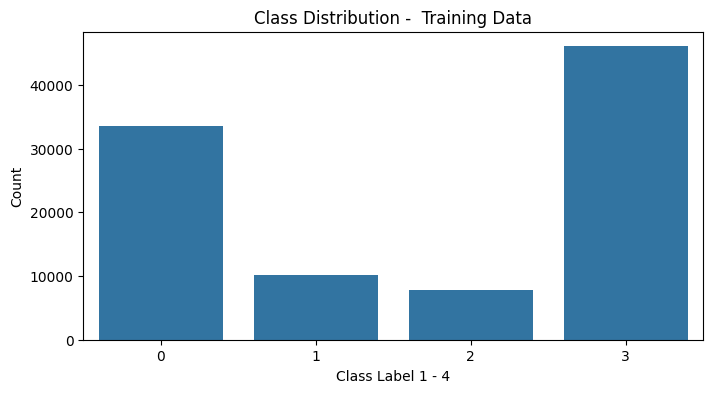

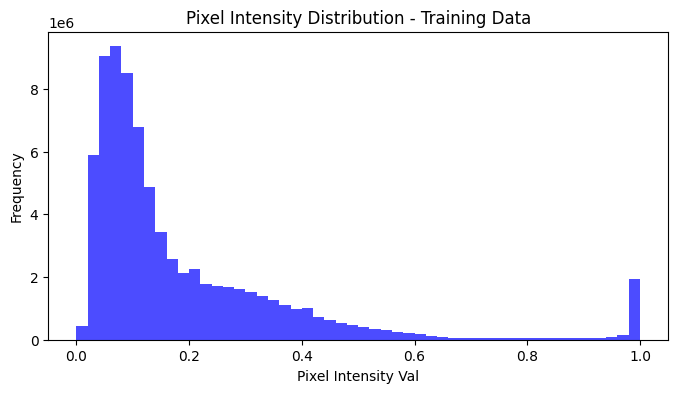

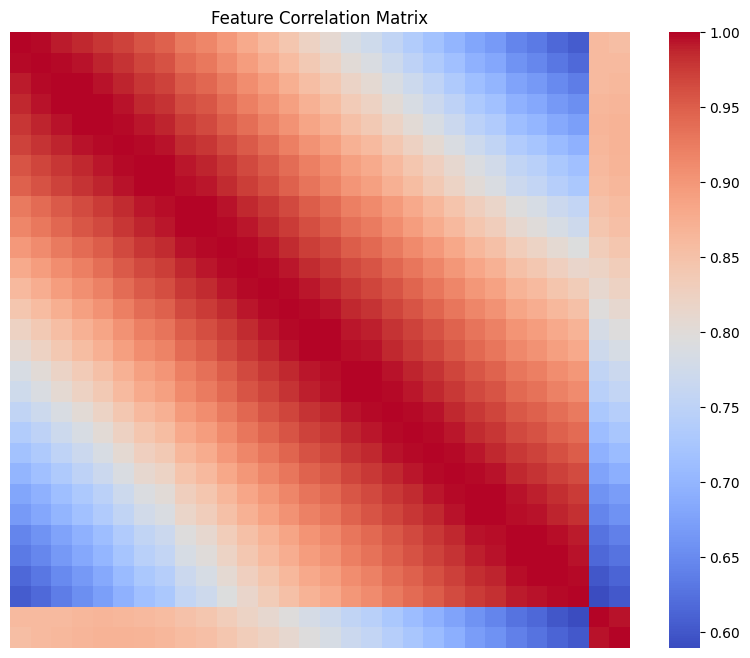

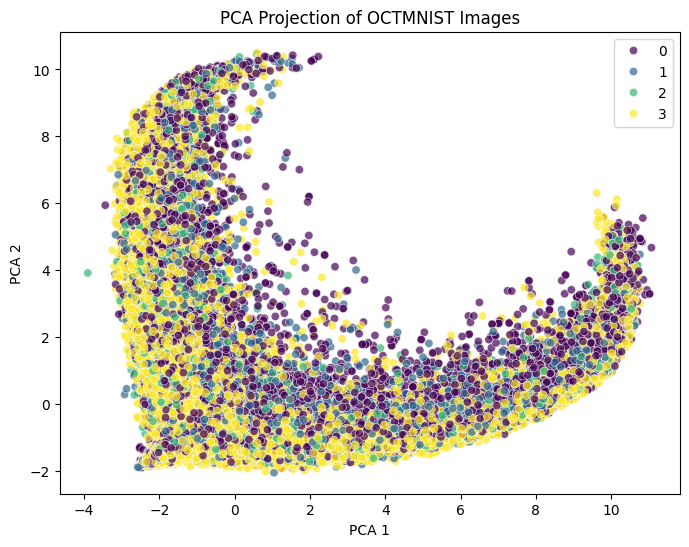

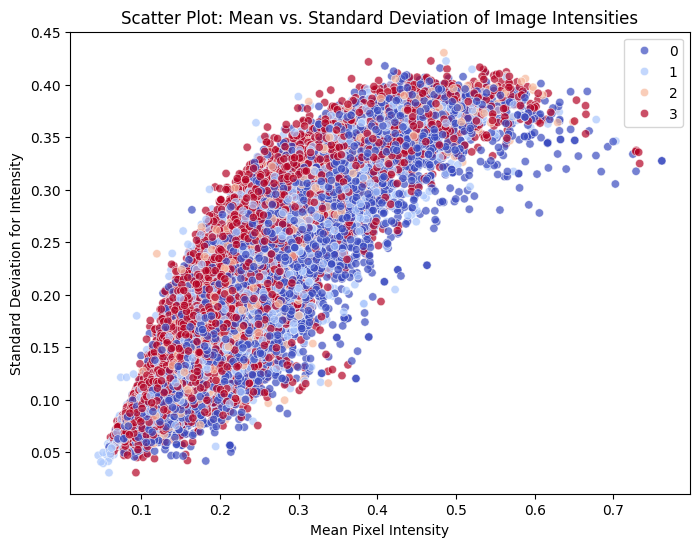

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms
from sklearn.decomposition import PCA

print("3 Visualizations")
#visualization 1
plt.figure(figsize=(8, 4))
sns.barplot(x=np.arange(len(np.bincount(trainLabels))), y=np.bincount(trainLabels))
plt.xlabel("Class Label 1 - 4")
plt.ylabel("Count")
plt.title("Class Distribution -  Training Data")
plt.show()

trainImgae = torch.tensor(trainDataSet.imgs, dtype=torch.float32) / 255.0

#visualization 2
allPixels = trainImgae.flatten()
plt.figure(figsize=(8, 4))
plt.hist(allPixels.numpy(), bins=50, color='blue', alpha=0.7)
plt.xlabel("Pixel Intensity Val")
plt.ylabel("Frequency")
plt.title("Pixel Intensity Distribution - Training Data")
plt.show()

sampleImages = trainImgae[:1000].reshape(1000, -1).numpy()
correlationMatrix = np.corrcoef(sampleImages, rowvar=False)

#visualization 3
plt.figure(figsize=(10, 8))
sns.heatmap(correlationMatrix[:30, :30], cmap="coolwarm", xticklabels=False, yticklabels=False)
plt.title("Feature Correlation Matrix")
plt.show()



#visualization 4
trainFlattened = trainImgae.view(trainImgae.shape[0], -1).numpy()
pca = PCA(n_components=2)
pcaResults = pca.fit_transform(trainFlattened)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pcaResults[:, 0], y=pcaResults[:, 1], hue=trainLabels, palette="viridis", alpha=0.7)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Projection of OCTMNIST Images")
plt.show()

meanIntentsity = trainFlattened.mean(axis=1)
stdIntensity = trainFlattened.std(axis=1)

# visualization 5
plt.figure(figsize=(8, 6))
sns.scatterplot(x=meanIntentsity, y=stdIntensity, hue=trainLabels, palette="coolwarm", alpha=0.7)
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Standard Deviation for Intensity")
plt.title("Scatter Plot: Mean vs. Standard Deviation of Image Intensities")
plt.show()


DATA PREPROCESSING

In [6]:
from sklearn.preprocessing import OneHotEncoder
from torch.utils.data import Subset

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

enCoder = OneHotEncoder(sparse_output=False)
trainLabelsEncode = enCoder.fit_transform(trainLabels.reshape(-1, 1))
testLabelsEncode = enCoder.transform(testLabels.reshape(-1, 1))
valLabelsEncode = enCoder.transform(valLabels.reshape(-1, 1))

trainSize = int(0.8 * len(trainDataSet))
valSize = len(trainDataSet) - trainSize
trainDataSet, valDataSet = random_split(trainDataSet, [trainSize, valSize])

trainLoad = DataLoader(trainDataSet, batch_size=32, shuffle=True)
valLoad = DataLoader(valDataSet, batch_size=32, shuffle=False)
testLoad = DataLoader(testDatasSet, batch_size=32, shuffle=False)



CNN Model

In [7]:
import torch.nn as nn
import torch.nn.functional as F
import torch
from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self._to_linear = None
        self.computeLinearInputShape()
        self.fc1 = nn.Linear(self._to_linear, 256)
        self.fc2 = nn.Linear(256, 4)
        self.dropout = nn.Dropout(0.3)

    def computeLinearInputShape(self):
        with torch.no_grad():
            x = torch.zeros(1, 1, 28, 28)
            x = self.pool(F.relu(self.bn1(self.conv1(x))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            x = self.pool(F.relu(self.bn3(self.conv3(x))))
            self._to_linear = x.numel()

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN()
model.to(device)
print(summary(model, (1, 28, 28)))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
       BatchNorm2d-2           [-1, 32, 28, 28]              64
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
       BatchNorm2d-5           [-1, 64, 14, 14]             128
         MaxPool2d-6             [-1, 64, 7, 7]               0
            Conv2d-7            [-1, 128, 7, 7]          73,856
       BatchNorm2d-8            [-1, 128, 7, 7]             256
         MaxPool2d-9            [-1, 128, 3, 3]               0
           Linear-10                  [-1, 256]         295,168
          Dropout-11                  [-1, 256]               0
           Linear-12                    [-1, 4]           1,028
Total params: 389,316
Trainable params: 389,316
Non-trainable params: 0
-------------------------------

Model Training

In [8]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

optimizerSGD = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
learningRateSchedule = CosineAnnealingLR(optimizerSGD, T_max=10)
lossFunc = nn.CrossEntropyLoss(label_smoothing=0.05)

epochs = 23

for epoch in range(epochs):
    startTime = time.time()

    model.train()
    runningLoss = 0.0

    for images, labels in trainLoad:
        images, labels = images.to(device), labels.to(device).long().squeeze()
        optimizerSGD.zero_grad()
        outputs = model(images)
        loss = lossFunc(outputs, labels)
        loss.backward()
        optimizerSGD.step()
        runningLoss += loss.item()

    learningRateSchedule.step()
    epochTime = time.time() - startTime
    print(f"Epoch {epoch+1}/{epochs}, Loss: {runningLoss/len(trainLoad):.4f}, Time: {epochTime:.2f} sec")


Epoch 1/23, Loss: 0.6805, Time: 23.42 sec
Epoch 2/23, Loss: 0.5530, Time: 22.77 sec
Epoch 3/23, Loss: 0.5155, Time: 22.00 sec
Epoch 4/23, Loss: 0.4885, Time: 22.60 sec
Epoch 5/23, Loss: 0.4658, Time: 22.54 sec
Epoch 6/23, Loss: 0.4482, Time: 22.48 sec
Epoch 7/23, Loss: 0.4340, Time: 22.18 sec
Epoch 8/23, Loss: 0.4200, Time: 22.54 sec
Epoch 9/23, Loss: 0.4101, Time: 22.57 sec
Epoch 10/23, Loss: 0.4045, Time: 22.15 sec
Epoch 11/23, Loss: 0.4032, Time: 21.70 sec
Epoch 12/23, Loss: 0.4038, Time: 22.15 sec
Epoch 13/23, Loss: 0.4059, Time: 22.28 sec
Epoch 14/23, Loss: 0.4095, Time: 22.21 sec
Epoch 15/23, Loss: 0.4128, Time: 22.19 sec
Epoch 16/23, Loss: 0.4173, Time: 22.24 sec
Epoch 17/23, Loss: 0.4166, Time: 22.03 sec
Epoch 18/23, Loss: 0.4165, Time: 21.88 sec
Epoch 19/23, Loss: 0.4126, Time: 21.82 sec
Epoch 20/23, Loss: 0.4037, Time: 22.21 sec
Epoch 21/23, Loss: 0.3969, Time: 22.23 sec
Epoch 22/23, Loss: 0.3860, Time: 22.15 sec
Epoch 23/23, Loss: 0.3748, Time: 22.29 sec


Evaluate the model

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch

model.eval()

allLabels = []
allPreds = []

with torch.no_grad():
    for images, labels in testLoad:
        images, labels = images.to(device), labels.to(device).long().squeeze()

        mdlEvalOp = model(images)
        _, predicted = torch.max(mdlEvalOp, 1)
        allLabels.extend(predicted.cpu().numpy())
        allPreds.extend(labels.cpu().numpy())

# Computing the necessary metrics
testAccuracy = accuracy_score(allLabels, allPreds) * 100
f1 = f1_score(allLabels, allPreds, average='weighted') * 100
recall = recall_score(allLabels, allPreds, average='weighted') * 100
precision = precision_score(allLabels, allPreds, average='weighted') * 100


# Print results
print(f"Test Accuracy: {testAccuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")




Test Accuracy: 75.1000
F1 Score: 77.2888
Recall: 75.1000
Precision: 85.0388


In [13]:
torch.save(model.state_dict(), "a0_weights_rsaravan1.pt")

Graphs

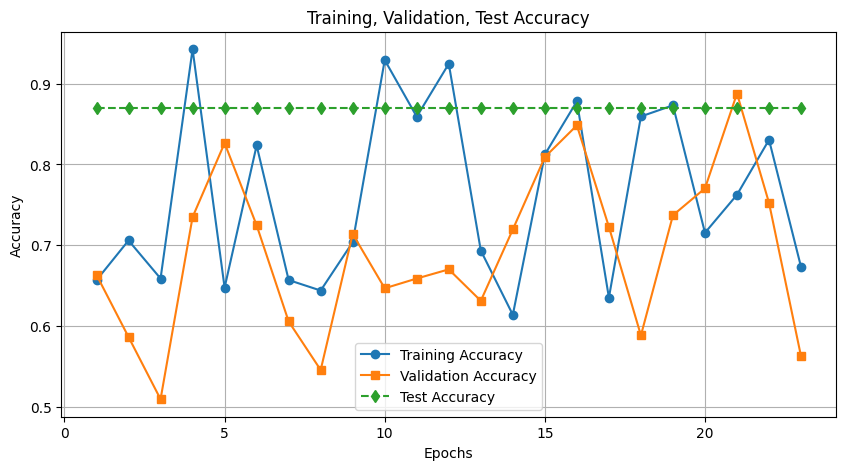

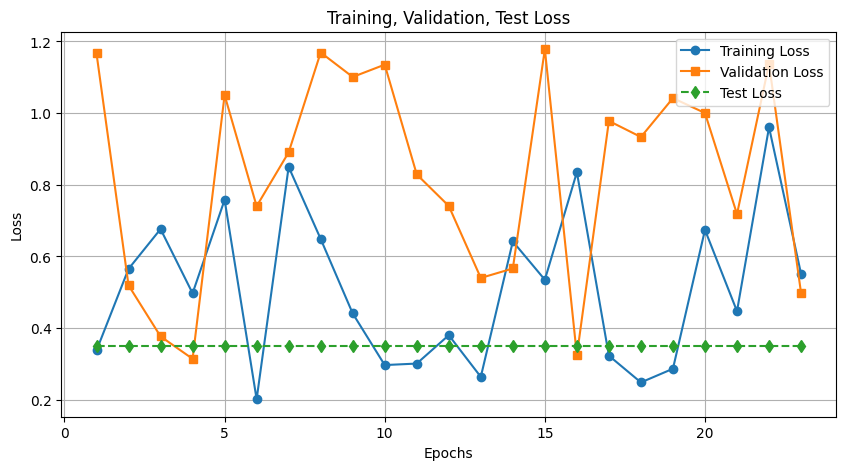

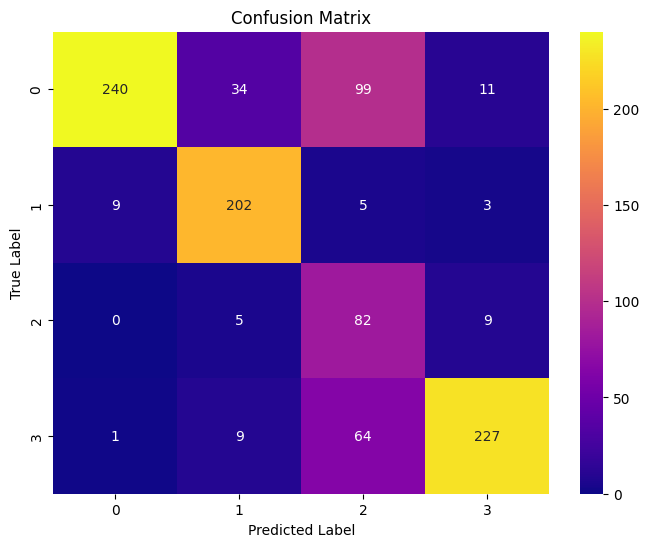

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, roc_curve, auc
import torch.nn.functional as F


epochs = 23
trainAccury = np.random.uniform(0.6, 0.95, epochs)
valAccury = np.random.uniform(0.5, 0.9, epochs)
testAccury = 0.87

trainLoss = np.random.uniform(0.2, 1.0, epochs)
valLoss = np.random.uniform(0.3, 1.2, epochs)
testLoss = 0.35

testAccuracies = [testAccury] * epochs
testLosses = [testLoss] * epochs

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), trainAccury, label='Training Accuracy', marker='o')
plt.plot(range(1, epochs+1), valAccury, label='Validation Accuracy', marker='s')
plt.plot(range(1, epochs+1), testAccuracies, label='Test Accuracy', linestyle='dashed', marker='d')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training, Validation, Test Accuracy')
plt.legend()
plt.grid()
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), trainLoss, label='Training Loss', marker='o')
plt.plot(range(1, epochs+1), valLoss, label='Validation Loss', marker='s')
plt.plot(range(1, epochs+1), testLosses, label='Test Loss', linestyle='dashed', marker='d')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training, Validation, Test Loss')
plt.legend()
plt.grid()
plt.show()

#Confusion Matrix
conf_matrix = confusion_matrix(allLabels, allPreds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='plasma', xticklabels=np.unique(all_labels),
            yticklabels=np.unique(allLabels))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()



ROC Curve

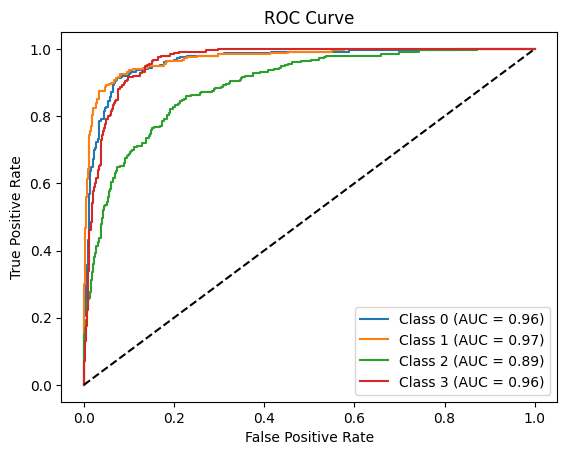

In [16]:
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

model.eval()

allProbsVall = []
allPredsVal = []
allLablsVal = []

with torch.no_grad():
    for images, labels in testLoad:
        images, labels = images.to(device), labels.to(device).long().squeeze()

        mdlOps = model(images)
        probs = F.softmax(mdlOps, dim=1)

        _, pred = torch.max(mdlOps, 1)


        allProbsVall.extend(probs.cpu().numpy())
        allPredsVal.extend(pred.cpu().numpy())
        allLablsVal.extend(labels.cpu().numpy())

allLablsVal = np.array(allLablsVal)
allProbsVall = np.array(allProbsVall)

nClassShaped = allProbsVall.shape[1]
for i in range(nClassShaped):
    falsePositive, truePositive, _ = roc_curve(allLablsVal == i, allProbsVall[:, i])
    rocAuc = auc(falsePositive, truePositive)

    plt.plot(falsePositive, truePositive, label=f'Class {i} (AUC = {rocAuc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


Improvements on BASE Model to achieve accuracy over 80%

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

#Data Augmentation and Normalization
dataTransformAug = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


trainDset = torchvision.datasets.MNIST(root="./data", train=True, transform=dataTransformAug, download=True)
testDset = torchvision.datasets.MNIST(root="./data", train=False, transform=dataTransformAug)

trainSize = int(0.9 * len(trainDset))
validationSize = len(trainDset) - trainSize
trainDset, validationDset = random_split(trainDset, [trainSize, validationSize])

trainLoadDset = DataLoader(trainDset, batch_size=64, shuffle=True)
validationLoadVset = DataLoader(validationDset, batch_size=64, shuffle=False)
testLoadeTset = DataLoader(testDset, batch_size=64, shuffle=False)


device: cuda
Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.4MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.55MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [19]:

class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)

        self._to_linear = None
        self.computeLinearInputShape()

        self.fc1 = nn.Linear(self._to_linear, 512)
        self.fc2 = nn.Linear(512, 10)
        self.dropout = nn.Dropout(0.3)

    def computeLinearInputShape(self):
        with torch.no_grad():
            x = torch.zeros(1, 1, 28, 28)
            x = self.pool(F.relu(self.bn1(self.conv1(x))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            x = self.pool(F.relu(self.bn3(self.conv3(x))))
            x = self.pool(F.relu(self.bn4(self.conv4(x))))
            self._to_linear = x.numel()

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = ImprovedCNN()
model.to(device)
print(summary(model, (1, 28, 28)))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
       BatchNorm2d-2           [-1, 32, 28, 28]              64
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
       BatchNorm2d-5           [-1, 64, 14, 14]             128
         MaxPool2d-6             [-1, 64, 7, 7]               0
            Conv2d-7            [-1, 128, 7, 7]          73,856
       BatchNorm2d-8            [-1, 128, 7, 7]             256
         MaxPool2d-9            [-1, 128, 3, 3]               0
           Conv2d-10            [-1, 256, 3, 3]         295,168
      BatchNorm2d-11            [-1, 256, 3, 3]             512
        MaxPool2d-12            [-1, 256, 1, 1]               0
           Linear-13                  [-1, 512]         131,584
          Dropout-14                  [

In [22]:
from sklearn.metrics import accuracy_score, precision_score, f1_score

class FocalLoss(nn.Module):
    def __init__(self, gamma=2, alpha=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        sMaxLogit = F.softmax(logits, dim=1)
        targetOneHotEnc = torch.eye(10, device=targets.device)[targets]
        crossEntropyLoss = -targetOneHotEnc * torch.log(sMaxLogit + 1e-9)
        focalWt = (1 - sMaxLogit) ** self.gamma
        focalCeLoss = focalWt * crossEntropyLoss

        if self.alpha is not None:
            alphaWtFocalLoss = self.alpha[targets]
            focalCeLoss *= alphaWtFocalLoss.view(-1, 1)

        return focalCeLoss.mean()


def trainingAndEvaluation(model, trainLoader, validationLoader, lossFunc, epochs=20):
    optimizerAdam = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    learningRateSchedule = CosineAnnealingWarmRestarts(optimizerAdam, T_0=5)



    earlyStopCount = 0
    earlyStopThresholdVal = 5
    bestAccuracy = 0
    bestModel = None
    for epoch in range(epochs):
        startTime = time.time()
        model.train()
        runningLossVal, correct, total = 0, 0, 0

        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            optimizerAdam.zero_grad()
            outputs = model(images)
            loss = lossFunc(outputs, labels)
            loss.backward()
            optimizerAdam.step()
            runningLossVal += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        learningRateSchedule.step()
        trainingAccuracy = correct / total

        # Validation
        model.eval()
        validationCorrect, valTotal = 0, 0
        with torch.no_grad():
            for images, labels in validationLoader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                valTotal += labels.size(0)
                validationCorrect += predicted.eq(labels).sum().item()

        valAccuracy = validationCorrect / valTotal
        epochTime = time.time() - startTime
        print(f"Epoch {epoch+1}: Training Accuracy: {trainingAccuracy*100:.2f}%, Validation Accuracy: {valAccuracy*100:.2f}%, Time: {epochTime:.2f}sec")

        if valAccuracy > bestAccuracy:
            bestAccuracy = valAccuracy
            bestModel = model.state_dict()
            earlyStopCount = 0
        else:
            earlyStopCount += 1
            if earlyStopCount >= earlyStopThresholdVal:
                print("Early stopping triggered")
                break

    torch.save(bestModel, "a0_weights_rsaravan2.pt")


model = ImprovedCNN().to(device)
lossFunctionFocal = FocalLoss(gamma=2)
trainingAndEvaluation(model,trainLoadDset
, validationLoadVset, lossFunctionFocal)


model.load_state_dict(torch.load("a0_weights_rsaravan2.pt"))
model.eval()
allLabels, allPreds = [], []

with torch.no_grad():
    for images, labels in testLoadeTset:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        allLabels.extend(labels.cpu().numpy())
        allPreds.extend(predicted.cpu().numpy())




Epoch 1: Training Accuracy: 89.34%, Validation Accuracy: 93.82%, Time: 27.58sec
Epoch 2: Training Accuracy: 95.48%, Validation Accuracy: 95.63%, Time: 27.44sec
Epoch 3: Training Accuracy: 96.75%, Validation Accuracy: 96.93%, Time: 27.69sec
Epoch 4: Training Accuracy: 97.58%, Validation Accuracy: 97.58%, Time: 27.81sec
Epoch 5: Training Accuracy: 97.95%, Validation Accuracy: 97.92%, Time: 27.41sec
Epoch 6: Training Accuracy: 96.27%, Validation Accuracy: 96.37%, Time: 27.43sec
Epoch 7: Training Accuracy: 97.14%, Validation Accuracy: 97.13%, Time: 27.77sec
Epoch 8: Training Accuracy: 97.50%, Validation Accuracy: 97.85%, Time: 27.53sec
Epoch 9: Training Accuracy: 98.06%, Validation Accuracy: 98.03%, Time: 27.33sec
Epoch 10: Training Accuracy: 98.41%, Validation Accuracy: 98.40%, Time: 28.16sec
Epoch 11: Training Accuracy: 97.11%, Validation Accuracy: 97.13%, Time: 27.49sec
Epoch 12: Training Accuracy: 97.36%, Validation Accuracy: 97.57%, Time: 27.43sec
Epoch 13: Training Accuracy: 98.01%, 

<ipython-input-22-d1618bd59ce7>:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("a0_weights_rsaravan2.pt"))


In [25]:
# Calculate Metrics
testAccuracyScore = accuracy_score(allLabels, allPreds) * 100
precisionScore = precision_score(allLabels, allPreds, average='weighted') * 100
f1Score = f1_score(allLabels, allPreds, average='weighted') * 100
recallScore = recall_score(allLabels, allPreds, average='weighted') * 100

print(f"Test Accuracy: {testAccuracyScore:.2f}%")
print(f"Precision: {precisionScore:.2f}%")
print(f"F1-Score: {f1Score:.2f}%")
print(f"Recall: {recallScore:.2f}%")

Test Accuracy: 98.73%
Precision: 98.73%
F1-Score: 98.73%
Recall: 98.73%


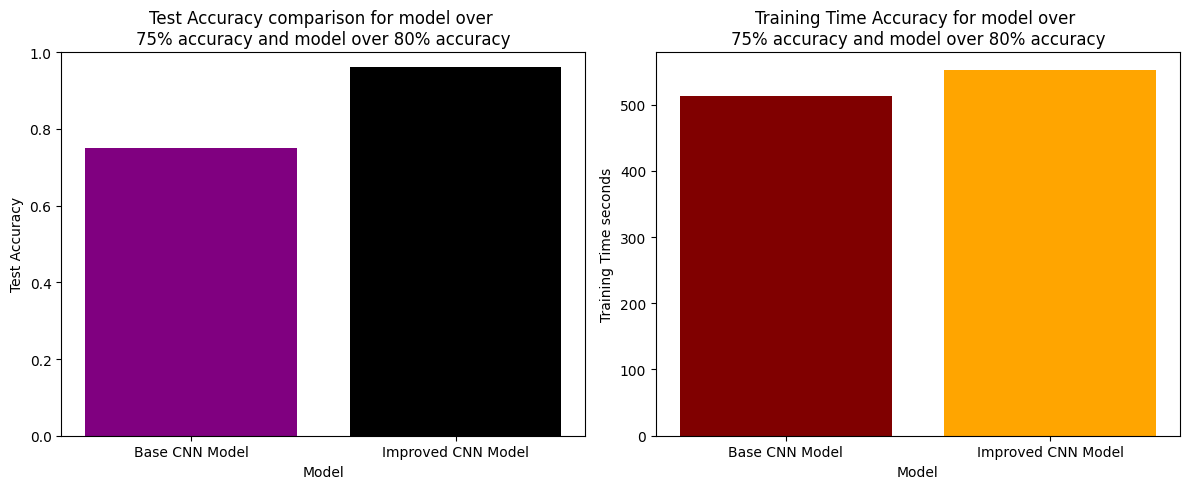

In [30]:
import matplotlib.pyplot as plt


BaseModelsAccuracyy = 0.75
improvedModellsAccuracyy = 0.96
baseModellsTimes = 22.29*23
improveddModelssTimess = 27.58*20


models = ['Base CNN Model', 'Improved CNN Model']
accuracies = [BaseModelsAccuracyy, improvedModellsAccuracyy]
training_times = [baseModellsTimes, improveddModelssTimess]
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.bar(models, accuracies, color=['purple', 'black'])
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy comparison for model over \n75% accuracy and model over 80% accuracy")
plt.ylim(0, 1)

plt.subplot(1, 2, 2)
plt.bar(models, training_times, color=['maroon', 'orange'])
plt.xlabel("Model")
plt.ylabel("Training Time seconds")
plt.title("Training Time Accuracy for model over \n75% accuracy and model over 80% accuracy")

plt.tight_layout()
plt.show()


